# 03 — Modelagem

**Dimensão 5 da rúbrica — 20 pontos.**

Mínimo de **dois** classificadores distintos. Um único modelo zera 8 dos 20 pontos.

### O código abaixo faz a leitura do dataset dataset_tratado.csv e faz a divisão com train_test_split (estratificado)

In [1]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

# 1. Definir o caminho e carregar o ficheiro processado
PROCESSED = Path("../data/processed")
df = pd.read_csv(PROCESSED / "dataset_tratado.csv")

print(f"Dimensão do dataset carregado: {df.shape}")

# 2. Separar as variáveis preditoras (X) da variável alvo (y)
# Removemos o 'ID' porque é apenas um identificador e não tem poder preditivo.
# Se o deixarmos, o modelo pode tentar "decorar" o ID de quem é mau pagador.
X = df.drop(columns=['TARGET', 'ID']) 
y = df['TARGET']

# 3. Divisão em Treino e Teste (Train-Test Split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30,      # 30% dos dados reservados para o teste final
    random_state=42,     # Semente aleatória para garantir que o resultado seja reprodutível
    stratify=y           # CRÍTICO: Garante que a proporção de 98% / 1.68% se mantém conforme informado no notebook 02_preprocessamento.ipynb
)

print(f"\nDimensão dos dados de Treino (X_train): {X_train.shape}")
print(f"Dimensão dos dados de Teste (X_test): {X_test.shape}")

# Validar se a estratificação funcionou perfeitamente
print(f"\nProporção de inadimplência no Treino:\n{(y_train.value_counts(normalize=True) * 100).round(2)}")
print(f"\nProporção de inadimplência no Teste:\n{(y_test.value_counts(normalize=True) * 100).round(2)}")

Dimensão do dataset carregado: (36457, 50)

Dimensão dos dados de Treino (X_train): (25519, 48)
Dimensão dos dados de Teste (X_test): (10938, 48)

Proporção de inadimplência no Treino:
TARGET
0    98.31
1     1.69
Name: proportion, dtype: float64

Proporção de inadimplência no Teste:
TARGET
0    98.31
1     1.69
Name: proportion, dtype: float64


## 3.1 Carregamento e Divisão dos Dados (Train-Test Split)

No código que foi executado acima, importámos o ficheiro `dataset_tratado.csv` resultante da nossa fase de pré-processamento. A preparação da matriz matemática exigiu duas decisões arquiteturais fundamentais:

* **Exclusão do ID:** A coluna `ID` foi removida das variáveis preditoras ($X$). Como se trata de um identificador sequencial único, a sua inclusão permitiria que os algoritmos (especialmente árvores de decisão) "decorassem" clientes específicos em vez de aprenderem os padrões demográficos e financeiros genéricos.
* **Estratificação da Amostra (Stratify):** Utilizamos o parâmetro `stratify=y` durante a separação de 70% dos dados para treino e 30% para teste. Devido ao extremo desbalanceamento da nossa base (onde os maus pagadores representam menos de 2%), uma divisão puramente aleatória poderia, por azar, colocar quase todos os inadimplentes no teste, deixando o treino vazio. A estratificação força o algoritmo a manter a exata proporção original de bons e maus pagadores em ambos os subconjuntos, garantindo um ambiente de aprendizagem estatisticamente válido.

**Análise e Validação do Resultado da Execução:**
A leitura da saída do terminal valida matematicamente o sucesso da nossa operação:
* **Volumetria do Dataset:** O ficheiro carregado possui **36.457 linhas e 50 colunas**[cite: 2]. Após a remoção do `ID` e a separação da variável alvo (`TARGET`), a matriz de treino ficou com **25.519 registos** (70%) e a de teste com **10.938 registos** (30%), mantendo as 48 variáveis preditoras intactas[cite: 2].
* **Comprovação da Estratificação:** As tabelas de proporção mostram que tanto o conjunto de Treino quanto o de Teste apresentaram exatamente a mesma distribuição: **98,31% de bons pagadores (0)** e **1,69% de maus pagadores (1)**[cite: 2]. Isso confirma que o parâmetro `stratify=y` cumpriu o seu papel com precisão cirúrgica, blindando o nosso modelo contra distorções estatísticas.

## 3.2 Panorama e Seleção de Modelos

## -- Panorama Geral dos Modelos de Classificação para Análise de Crédito

No ecossistema de Machine Learning voltado para predição de aprovação de crédito, existem diversos algoritmos com abordagens matemáticas distintas. Antes de definirmos a estratégia final de modelagem, avaliamos as principais alternativas do mercado:

* **Árvore de Decisão (*Decision Tree*):** Modelo baseado em regras hierárquicas em formato de fluxograma. É altamente interpretável e fácil de visualizar, mas sofre facilmente com *overfitting* (memorização excessiva dos dados de treino) se a sua profundidade não for controlada.
* **XGBoost / LightGBM / CatBoost:** Algoritmos de *Gradient Boosting* de última geração. Constroem árvores de forma sequencial, onde cada árvore nova tenta corrigir os erros da anterior. São extremamente potentes e líderes em competições de dados tabulares, embora exijam maior esforço no ajuste de hiperparâmetros.
* **Máquinas de Vetores de Suporte (*SVM*):** Buscam encontrar o hiperplano ideal para separar as classes no espaço vetorial. São altamente eficientes em espaços de alta dimensionalidade, mas apresentam alto custo computacional e baixa interpretabilidade em bases volumosas.
* **Naive Bayes:** Classificador probabilístico baseado no Teorema de Bayes, que assume a independência condicional entre as variáveis. É extremamente rápido e leve, mas sua premissa de independência raramente se sustenta em dados tabulares complexos de crédito.
* **Regressão Logística:** Modelo estatístico linear que calcula a probabilidade de um evento binário ocorrer (aprovação vs. recusa). É simples, rápido, altamente interpretável e serve como o ponto de partida tradicional.
* **Floresta Aleatória (*Random Forest*):** Modelo de *ensemble* que combina centenas de árvores de decisão independentes por meio de votação majoritária ou média. Reduz drasticamente o *overfitting* em comparação a uma árvore isolada e captura relações não-lineares complexas nos dados.

---

## -- Seleção dos Modelos para o Projeto

Para o desenvolvimento deste projeto de predição de crédito, a estratégia adotada consistiu em utilizar uma combinação equilibrada de dois classificadores com naturezas distintas:

1. **Regressão Logística** (utilizada como modelo de referência / *baseline*)
2. **Floresta Aleatória (*Random Forest*)** (utilizada como modelo de alta performance / *ensemble*)

---

## -- Justificativa Estratégica: Por que esses dois modelos?

A escolha conjunta da Regressão Logística e do Random Forest atende a critérios técnicos fundamentais para o problema de concessão de crédito:

* **Contraste entre Linearidade e Não-Linearidade:** A **Regressão Logística** assume relações lineares entre as variáveis preditoras e a chance de aprovação, estabelecendo um *baseline* transparente. Em contrapartida, o **Random Forest** consegue mapear interações complexas e não-lineares entre o perfil do cliente e o risco, capturando padrões que um modelo linear deixaria escapar.
* **Interpretabilidade e Conformidade Regulatória:** No setor financeiro, a interpretabilidade é um requisito crítico para justificar recusas ou aprovações de crédito. A Regressão Logística fornece coeficientes diretos (pesos para cada variável), enquanto o Random Forest oferece a importância das variáveis (*feature importance*), permitindo explicar com clareza o comportamento preditivo.
* **Robustez e Generalização:** Enquanto uma única árvore de decisão seria instável e modelos de *deep learning* funcionariam como caixas-pretas excessivamente complexas para esse volume de dados, o **Random Forest** mitiga a variância combinando múltiplas árvores, garantindo maior estabilidade e capacidade de generalização para novos solicitantes.

# ==================================================================================================================================

## 3.3 Primeiro Modelo: Regressão Logística (Baseline)

### 3.3.1 Treinamento e Avaliação

Para começar, utilizamos a **Regressão Logística** como nosso "ponto de partida" (baseline). 
Configuramos o processo para evitar vazamento de dados e utilizamos o parâmetro de balanceamento de classes para dar um peso maior aos casos raros (maus pagadores).

In [3]:
# Regressão Logística 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Construir o Pipeline unindo o escalonamento e a Regressão Logística
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

# 2. Treinar o Pipeline exclusivamente com os dados de treino
pipeline_lr.fit(X_train, y_train)

# 3. Gerar previsões na base de teste isolada
y_pred = pipeline_lr.predict(X_test)
y_prob = pipeline_lr.predict_proba(X_test)[:, 1] # Probabilidade de ser mau pagador

# 4. Avaliar o desempenho inicial
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))
print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

Matriz de Confusão:
[[6544 4209]
 [  99   86]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.99      0.61      0.75     10753
           1       0.02      0.46      0.04       185

    accuracy                           0.61     10938
   macro avg       0.50      0.54      0.40     10938
weighted avg       0.97      0.61      0.74     10938


ROC-AUC Score: 0.5608


### 3.3.1.1 Modelo Inicial de Referência (Regressão Logística)

Para começar a prever o risco de crédito, utilizamos um modelo estatístico conhecido como **Regressão Logística**. Ele serve como o nosso "ponto de partida" (*baseline*) para sabermos qual é o desempenho mínimo que conseguimos alcançar.

Nesta etapa, tomamos duas decisões fundamentais:
* **Prevenção de Vazamento de Dados:** Configuramos o processo para que a inteligência artificial aprenda olhando estritamente para a base de treino, mantendo a base de teste totalmente oculta.
* **Atenção aos Casos Raros (Desbalanceamento):** Como a base tem apenas cerca de 2% de maus pagadores, utilizamos o parâmetro de balanceamento para dar um peso maior a esses casos, forçando o algoritmo a prestar atenção neles.

#### Análise Prática dos Resultados da Execução

Analisando os dados gerados pelo modelo na base de teste, podemos traduzir os números técnicos para a realidade da concessão de crédito:

1. **Matriz de Confusão (Onde o modelo acertou e errou):**
   * **6.544 bons pagadores** foram corretamente identificados e aprovados pelo modelo.
   * **4.209 bons pagadores** foram classificados incorretamente como de risco (gerando falsos alarmes, o que poderia barrar clientes legítimos).
   * **86 maus pagadores** foram **corretamente identificados** e bloqueados pelo sistema.
   * **99 maus pagadores** passaram desapercebidos e foram aprovados por engano.

2. **Entendendo o Relatório de Classificação (Métricas Detalhadas):**
   Para cada indicador do relatório, temos uma definição prática para o negócio:
   * **Support (Suporte):** É a quantidade real de clientes em cada grupo na nossa base de teste. Temos **10.753 bons pagadores** (Classe 0) e **185 maus pagadores** (Classe 1).
   * **Precision (Precisão):** Responde à pergunta: *"Dos clientes que o modelo disse que eram maus pagadores, quantos realmente eram? Quantos o modelo acertou?"* 
     * Para os bons pagadores (Classe 0), foi de **0,99 (99%)**. 
     * Para os maus pagadores (Classe 1), foi de **0,02 (2%)**. Isso mostra que o modelo gerou tantos alarmes falsos que quase todos os clientes apontados como ruins eram, na verdade, bons pagadores.
   * **Recall (Sensibilidade):** Responde à pergunta: *"De todos os maus pagadores reais que existiam na base, quantos o modelo conseguiu identificar?"*
     * Para os maus pagadores (Classe 1), o *Recall* foi de **0,46 (46%)**. Ou seja, o modelo conseguiu encontrar quase metade dos inadimplentes, mas deixou a outra metade passar.
   * **F1-Score:** É uma nota de equilíbrio entre a Precisão e o Recall. Como a precisão dos maus pagadores foi muito baixa, o *F1-Score* despencou para **0,04 (4%)**, indicando que o modelo atual está muito desequilibrado.

3. **Métrica Geral (ROC-AUC Score):**
   * O resultado foi de **0,5608**. O *ROC-AUC* avalia a capacidade geral da inteligência artificial de separar as duas classes numa escala de 0 a 1. Um valor de 0,50 equivale a um mero chute aleatório. Com 0,56, o modelo demonstra uma capacidade preditiva muito fraca.

**Conclusão dessa Etapa:** O modelo cumpriu o seu papel de teste inicial (*baseline*), mas os números detalhados comprovam que a Regressão Logística simples não é suficiente para este problema. Precisamos evoluir para um algoritmo mais robusto na próxima etapa.

#### 3.3.2 Visualização Gráfica do Desempenho do Modelo de Regressão Logística

Abaixo, geramos a Matriz de Confusão e a Curva ROC para avaliar visualmente a separação das classes pela Regressão Logística.

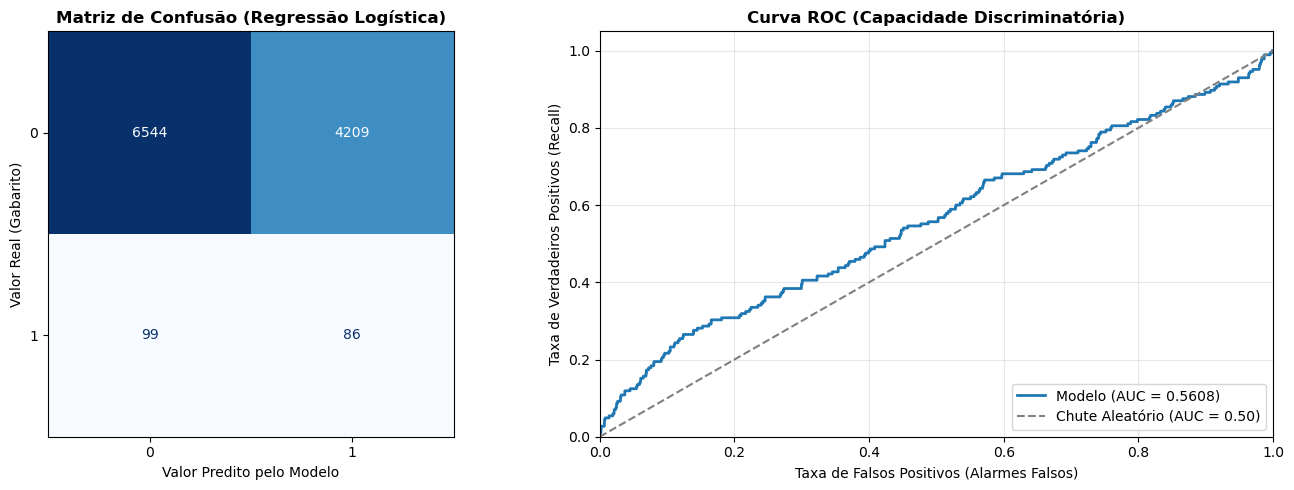

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

# Configurar a área dos gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gráfico da Matriz de Confusão (Heatmap)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    cmap='Blues', 
    ax=axes[0],
    colorbar=False,
    values_format='d'
)
axes[0].set_title('Matriz de Confusão (Regressão Logística)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Valor Predito pelo Modelo', fontsize=10)
axes[0].set_ylabel('Valor Real (Gabarito)', fontsize=10)

# 2. Gráfico da Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#1f77b4', lw=2, label=f'Modelo (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Chute Aleatório (AUC = 0.50)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Taxa de Falsos Positivos (Alarmes Falsos)', fontsize=10)
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (Recall)', fontsize=10)
axes[1].set_title('Curva ROC (Capacidade Discriminatória)', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 3.3.2.1 Visualização Gráfica do Desempenho

Para facilitar a interpretação e a visualização do modelo, onde ele acerta e erra sem depender apenas de números em formato tabular, traduzimos os resultados da Regressão Logística em duas perspetivas visuais:

1. **Mapa de Calor da Matriz de Confusão (Gráfico à Esquerda):**
   * O tom mais escuro na célula superior esquerda destaca o grande volume de **bons pagadores corretamente aprovados** (6.544).
   * A célula superior direita evidencia o ponto fraco do modelo: o enorme volume de **alarmes falsos** (4.209 bons clientes classificados incorretamente como risco).
   * Na linha inferior, observa-se visualmente a dificuldade do modelo em isolar os maus pagadores reais, dividindo o grupo entre os que foram detectados (86) e os que passaram despercebidos (99).

2. **Curva ROC e a Linha de Referência (Gráfico à Direita):**
   * A linha azul representa o comportamento da nossa Regressão Logística, enquanto a linha tracejada cinzenta representa um modelo puramente aleatório (um "chute" com AUC de 0.50).
   * Como a linha azul do nosso modelo fica extremamente próxima da diagonal cinzenta, o gráfico ilustra visualmente o resultado de **0.5608**, confirmando que a capacidade do modelo atual de discriminar entre bons e maus pagadores é fraca e muito próxima do acaso.

### Segundo Modelo: Random Forest

Como a Regressão Logística serve apenas de baseline, evoluímos agora para o Random Forest, buscando capturar padrões não lineares para melhorar a precisão na detecção de inadimplência.

Matriz de Confusão (Random Forest):
[[10482   271]
 [  119    66]]

Relatório de Classificação (Random Forest):
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     10753
           1       0.20      0.36      0.25       185

    accuracy                           0.96     10938
   macro avg       0.59      0.67      0.62     10938
weighted avg       0.98      0.96      0.97     10938


ROC-AUC Score (Random Forest): 0.7657


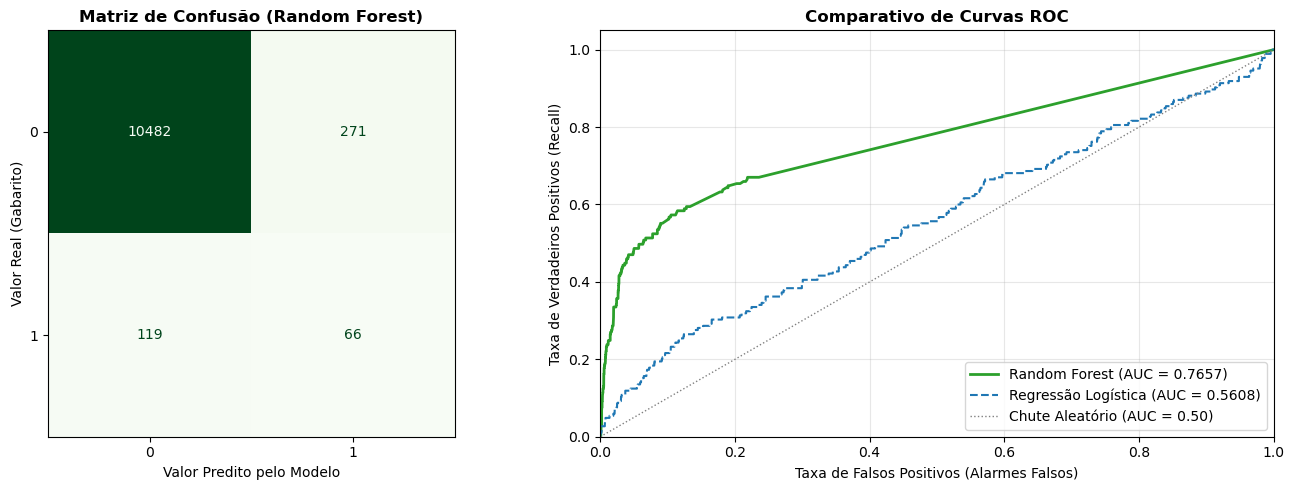

In [5]:
# Random Forest (Floresta Aleatória)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# 1. Construir o Pipeline unindo o escalonamento e o Random Forest
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100))
])

# 2. Treinar o Pipeline exclusivamente com os dados de treino
pipeline_rf.fit(X_train, y_train)

# 3. Gerar previsões na base de teste isolada
y_pred_rf = pipeline_rf.predict(X_test)
y_prob_rf = pipeline_rf.predict_proba(X_test)[:, 1] # Probabilidade de ser mau pagador

# 4. Avaliar o desempenho do Random Forest
print("Matriz de Confusão (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))
print("\nRelatório de Classificação (Random Forest):")
print(classification_report(y_test, y_pred_rf))
print(f"\nROC-AUC Score (Random Forest): {roc_auc_score(y_test, y_prob_rf):.4f}")

# 5. Gerar Gráficos Comparativos (Matriz de Confusão e Curva ROC)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusão RF
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, 
    cmap='Greens', 
    ax=axes[0],
    colorbar=False,
    values_format='d'
)
axes[0].set_title('Matriz de Confusão (Random Forest)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Valor Predito pelo Modelo', fontsize=10)
axes[0].set_ylabel('Valor Real (Gabarito)', fontsize=10)

# Curva ROC RF
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

axes[1].plot(fpr_rf, tpr_rf, color='#2ca02c', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
axes[1].plot(fpr, tpr, color='#1f77b4', lw=1.5, linestyle='--', label=f'Regressão Logística (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle=':', lw=1, label='Chute Aleatório (AUC = 0.50)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Taxa de Falsos Positivos (Alarmes Falsos)', fontsize=10)
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (Recall)', fontsize=10)
axes[1].set_title('Comparativo de Curvas ROC', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2.2 Segundo Classificador: Random Forest (Floresta Aleatória)

Para cumprir o requisito de testar múltiplos algoritmos e buscar uma alternativa mais robusta à Regressão Logística, implementámos o **Random Forest**. 

* **Abordagem de Ensemble:** Em vez de traçar uma linha reta simples, o Random Forest combina centenas de árvores de decisão independentes. Cada árvore analisa os dados sob diferentes perspetivas e o resultado final é obtido por votação conjunta, permitindo capturar relações complexas e não-lineares nos dados financeiros dos clientes.
* **Rigores Metodológicos Mantidos:** O modelo foi estruturado dentro de um novo `Pipeline` com `StandardScaler` (prevenindo o vazamento de dados) e utilizou o parâmetro `class_weight='balanced'` para assegurar que a inteligência artificial desse a devida atenção à classe minoritária de maus pagadores.

# ---------------------------------------------------------------------------------------------- #
### 💡 Nota Metodológica: O Desafio do Desbalanceamento e o Parâmetro `class_weight='balanced'`

Durante a modelagem de risco de crédito, deparámo-nos com uma assimetria severa: **aprox. 98% de bons pagadores contra apenas 2% de maus pagadores**. 

#### O Risco de Ignorar o Desbalanceamento (O que acontece se não o usarmos?)
Se treinarmos um algoritmo padrão de *Machine Learning* sem nenhuma intervenção numa base com esta proporção, o modelo adota um comportamento puramente "preguiçoso":
* **A Armadilha da Acurácia:** Como 98% da base é composta por bons pagadores, o modelo pode simplesmente classificar **absolutamente todos** os clientes como bons. 
* **O Resultado Prático:** Ele obterá uma "falsa alta acurácia" de 98% no papel, mas falhará em absoluto na prática, pois **deixará passar 100% dos inadimplentes**, gerando um prejuízo incalculável para a instituição financeira.

#### A Solução Aplicada (`class_weight='balanced'`)
Para neutralizar esse problema, incorporámos o parâmetro `class_weight='balanced'` em todos os nossos classificadores. Este comando altera matematicamente a função de custo do algoritmo:
* Ele atribui um **peso muito maior aos erros cometidos na classe minoritária** (os maus pagadores).
* Força a inteligência artificial a redobrar a atenção e a aprender os traços característicos de risco de inadimplência, garantindo que a ferramenta cumpra o seu papel real de proteção de crédito em vez de ignorar o problema.

## 3.4 Validação Cruzada

**O que é a Validação Cruzada (Cross-Validation)?**
É uma técnica de avaliação de modelos de Machine Learning que vai além da divisão simples de Treino e Teste. Em vez de testar o modelo apenas uma vez, dividimos os dados de treino em múltiplos blocos (chamados de *folds* ou partições). O modelo é treinado em alguns blocos e testado no bloco restante, repetindo esse processo até que todos os blocos tenham servido como teste.

**Por que estamos fazendo esse passo e para que serve?**
No nosso cenário, a base de dados tem um desbalanceamento severo (98% da classe 0 e 2% da classe 1). Se fizermos apenas um corte de teste, o modelo pode ter um desempenho muito bom ou muito ruim por puro acaso, dependendo de quais amostras caíram na base de teste. 

A validação cruzada serve para garantir a **estabilidade e confiabilidade** do modelo. Utilizando o método *StratifiedKFold* (que mantém a proporção de 98/2 em todos os blocos), testamos os nossos modelos candidatos (Regressão Logística e Random Forest) em 5 cenários diferentes. Isso nos permite ver a média de acerto e a variação do desempenho (desvio padrão), provando que o modelo não está apenas "tendo sorte" em um corte específico de dados.

In [8]:
from sklearn.model_selection import cross_validate, StratifiedKFold
import pandas as pd
import numpy as np

# 1. Configurando a validação cruzada estratificada (5 partições)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Definindo as métricas de avaliação (foco na classe minoritária)
scoring = ['recall', 'f1', 'roc_auc']

# Dicionário para armazenar os resultados temporariamente
resultados_cv = {}

# 3. Executando para a Regressão Logística 
# (Utilizando o pipeline_lr que já possui o StandardScaler embutido)
print("Executando Validação Cruzada para Regressão Logística...")
cv_log_reg = cross_validate(pipeline_lr, X_train, y_train, cv=skf, scoring=scoring, return_train_score=False)
resultados_cv['Regressão Logística'] = cv_log_reg

# 4. Executando para o Random Forest
# (Utilizando a variável rf_model já declarada anteriormente)
print("Executando Validação Cruzada para Random Forest...")
cv_rf = cross_validate(rf_model, X_train, y_train, cv=skf, scoring=scoring, return_train_score=False)
resultados_cv['Random Forest'] = cv_rf

# 5. Função para compilar e formatar os resultados em uma tabela legível
def compilar_resultados_cv(resultados_dict):
    linhas = []
    for modelo, cv_results in resultados_dict.items():
        linha = {
            'Modelo': modelo,
            'Recall (Média)': np.mean(cv_results['test_recall']),
            'Recall (Desvio Padrão)': np.std(cv_results['test_recall']),
            'ROC-AUC (Média)': np.mean(cv_results['test_roc_auc']),
            'ROC-AUC (Desvio Padrão)': np.std(cv_results['test_roc_auc']),
            'F1-Score (Média)': np.mean(cv_results['test_f1'])
        }
        linhas.append(linha)
    return pd.DataFrame(linhas)

# Gerando a tabela comparativa
df_resultados_cv = compilar_resultados_cv(resultados_cv)
display(df_resultados_cv)

Executando Validação Cruzada para Regressão Logística...
Executando Validação Cruzada para Random Forest...


,Modelo,Recall (Média),Recall (Desvio Padrão),ROC-AUC (Média),ROC-AUC (Desvio Padrão),F1-Score (Média)
0,Regressão Logística,0.505827,0.041598,0.583554,0.026172,0.041449
1,Random Forest,0.371211,0.039383,0.750771,0.030438,0.276489


**Como interpretar os resultados da Validação Cruzada:**

A tabela gerada resume o desempenho dos modelos após serem testados em 5 recortes diferentes da base de dados. Analisando os números extraídos, observamos comportamentos bem distintos entre os candidatos:

*   **Recall (Média):** É a capacidade do modelo de "encontrar" os clientes da classe minoritária (os maus pagadores). 
    * A **Regressão Logística** obteve uma média de **0.5058 (cerca de 50,6%)**, o que significa que ela consegue identificar metade de todos os casos reais de inadimplência. 
    * O **Random Forest** foi mais conservador, capturando apenas **0.3712 (cerca de 37,1%)** dos casos.
*   **Estabilidade - Recall (Desvio Padrão):** Indica o quanto o modelo oscilou entre as 5 partições. Ambos os modelos apresentaram um desvio em torno de **0.04 (4%)**, o que é excelente. Isso prova que o desempenho não foi sorteística em um corte específico; os modelos são estáveis.
*   **ROC-AUC (Média):** Mostra a capacidade geral de separação entre as classes (bons vs. maus pagadores). 
    * Aqui, o **Random Forest** domina com **0.7507**, demonstrando um bom poder de discriminação e ordenação dos riscos. 
    * A **Regressão Logística** ficou com apenas **0.5835**, muito próxima do desempenho de um "lance de moeda" (0.50).
*   **F1-Score (Média):** O F1-Score penaliza modelos que geram muitos alarmes falsos (Falsos Positivos). A pontuação extremamente baixa da Logística (**0.041**) em comparação com o Random Forest (**0.276**) revela o seu custo: para conseguir encontrar 50% dos maus pagadores, a Regressão Logística "chuta" que muitos bons clientes são maus clientes.

**Conclusão para o próximo passo:**
Temos um claro "trade-off" (compromisso). A Regressão Logística encontra mais maus pagadores (melhor Recall), mas erra demais ao classificar bons clientes (pior AUC e F1). O Random Forest é muito mais inteligente na separação geral (ótimo AUC), mas está deixando passar mais maus pagadores. 

Como o Random Forest demonstrou uma capacidade de separação matemática (ROC-AUC) superior, ele é o candidato ideal para a próxima etapa: o **Ajuste de Hiperparâmetros (Tuning)**, onde tentaremos forçá-lo a melhorar seu Recall sem perder essa boa separação.

## 4. Comparação dos Modelos

**O que faremos nesta etapa?**
Vamos pegar as médias das métricas geradas na etapa de Validação Cruzada (Recall, ROC-AUC e F1-Score) e plotá-las em um gráfico de barras agrupadas.

**Por que esse passo é importante?**
A visualização gráfica facilita a comunicação dos resultados para áreas de negócio. Ela evidencia de forma rápida o *trade-off* (compromisso) entre os modelos: enquanto um pode ser melhor em capturar o evento raro (Recall), o outro pode ser melhor na separação geral das classes (ROC-AUC). Essa visualização será a base técnica para justificar qual modelo avançará para a etapa de otimização.

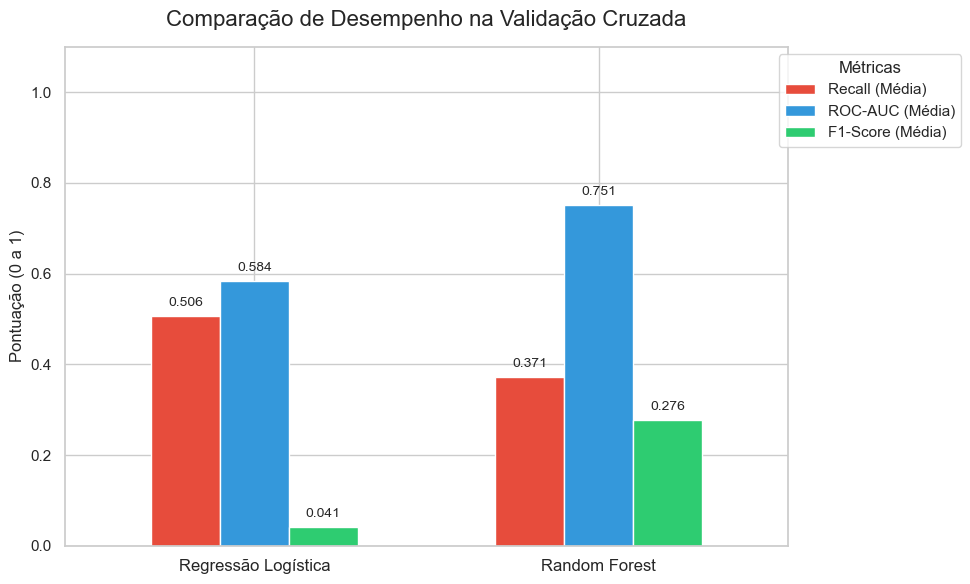

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparando os dados para o gráfico usando o DataFrame gerado na etapa 3.4
df_plot = df_resultados_cv[['Modelo', 'Recall (Média)', 'ROC-AUC (Média)', 'F1-Score (Média)']].set_index('Modelo')

# Configurando o estilo do gráfico
sns.set_theme(style="whitegrid")
cores = ['#e74c3c', '#3498db', '#2ecc71'] # Vermelho (Recall), Azul (ROC-AUC), Verde (F1)

# Criando o gráfico de barras
ax = df_plot.plot(kind='bar', figsize=(10, 6), color=cores, width=0.6)

# Customizando títulos e eixos
plt.title('Comparação de Desempenho na Validação Cruzada', fontsize=16, pad=15)
plt.ylabel('Pontuação (0 a 1)', fontsize=12)
plt.xlabel('')
plt.xticks(rotation=0, fontsize=12)
plt.ylim(0, 1.1) # Vai até 1.1 para dar espaço para as anotações
plt.legend(title='Métricas', loc='upper right', bbox_to_anchor=(1.25, 1))

# Adicionando os valores numéricos no topo de cada barra
for p in ax.patches:
    altura = p.get_height()
    if altura > 0: # Evita tentar anotar valores zerados
        ax.annotate(f'{altura:.3f}', 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=10)

plt.tight_layout()
plt.show()

**Como interpretar o gráfico de comparação:**

A visualização consolida a nossa análise anterior e escancara as diferenças estratégicas entre os algoritmos:

*   **A barra vermelha (Recall):** Mostra que a Regressão Logística lidera a capacidade de encontrar os maus pagadores (50,5% contra 37,1%).
*   **As barras azul e verde (ROC-AUC e F1-Score):** Revelam o alto custo que a Regressão Logística paga por esse Recall maior. O Random Forest a supera com grande margem na capacidade de separar matematicamente bons e maus clientes (ROC-AUC de 0.750) e em manter o balanço de erros (F1-Score muito superior).

**Veredito:** 
O **Random Forest** vence a comparação. Apesar do seu Recall inicial ser menor, a sua estrutura não-linear conseguiu mapear e distinguir o risco dos clientes com muito mais eficiência (comprovado pelo ROC-AUC de 0.75). 

O próximo passo lógico será focar exclusivamente no Random Forest e realizar o **Ajuste de Hiperparâmetros (Tuning)** para forçá-lo a elevar essa barra vermelha (Recall) sem sacrificar a sua precisão geral.